In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("customer_churn_data.csv")

In [3]:
df.shape
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [4]:
df.isnull().sum()

CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

In [5]:
df.drop('CustomerID',axis=1,inplace=True)

In [20]:
df.to_csv("cleaned_customer_churn.csv", index=False)

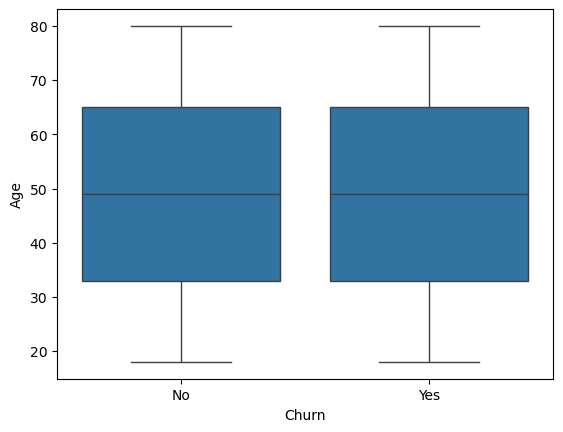

In [7]:
sns.boxplot(x='Churn',y='Age',data=df)
plt.show()

### Age vs Churn Analysis
- The median age for both churned and non-churned customers is around 50.
- The distribution of age is quite similar for both groups.
- This suggests that age is not a strong factor influencing customer churn.  
**Conclusion:**
Age does not significantly impact whether a customer will churn.

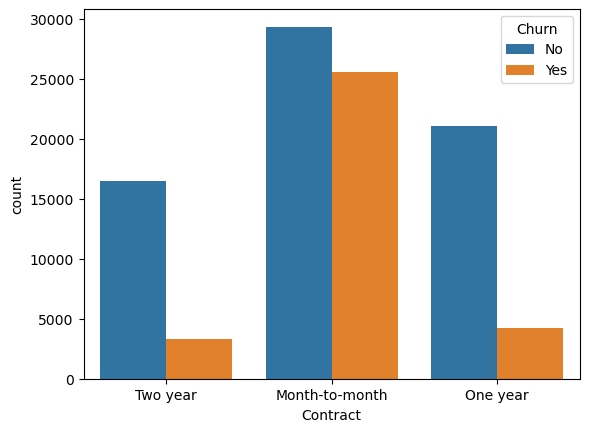

In [8]:
sns.countplot(x='Contract',hue='Churn',data=df)
plt.show()

### Contract Type vs Churn Analysis
- Customers with **month-to-month contracts** have a significantly higher churn rate compared to other contract types.
- Customers with **one-year and two-year contracts** are much less likely to churn.
- The number of churned customers is highest in the month-to-month category.

**Conclusion:**
Contract type is a strong factor influencing customer churn. Customers on short-term (month-to-month) contractsare more likely to leave.

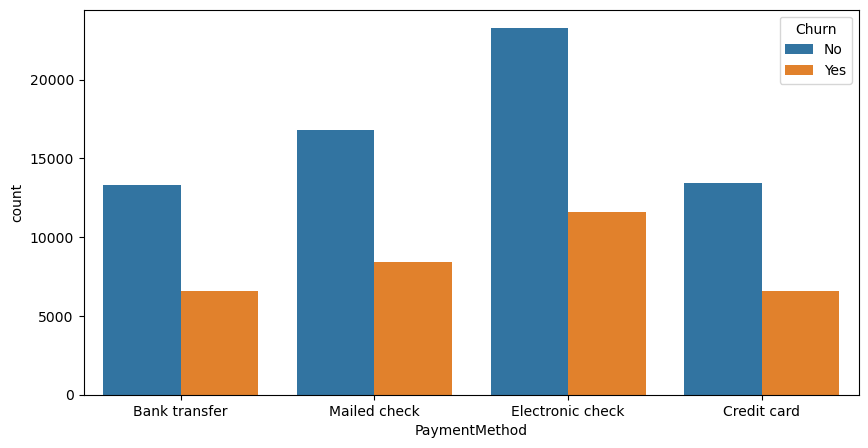

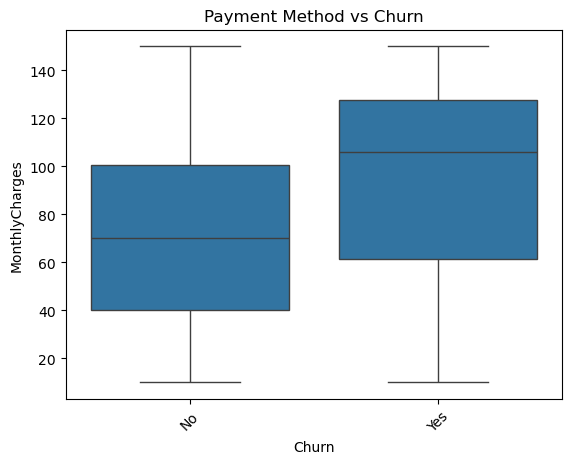

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn',data=df)
plt.show()
sns.boxplot(x='Churn', y='MonthlyCharges',data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

### Monthly Charges vs Churn Analysis:
- Customers who churned tend to have **higher monthly charges** comapared to those who did not churn.
- The median monthly charge for churned customers is noticeable higher.
- There is a clear upward shift in the distribution for churned customers.
**Conclusion:**
Higher monthly charges are associated with increased customer churn.

### Business Recommendation: 
Companies should consider offering discounts,better pricing plans, or additional value to customers with higher monthly charges to reduce churn.

In [10]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in ['Gender', 'Contract', 'PaymentMethod', 'Churn']:
    df[col]=le.fit_transform(df[col])

In [11]:
x=df.drop('Churn',axis=1)
y=df['Churn']

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LogisticRegression 
model=LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [14]:
from sklearn.metrics import accuracy_score, classification_report
y_pred=model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.72435
              precision    recall  f1-score   support

           0       0.76      0.86      0.81     13294
           1       0.62      0.45      0.52      6706

    accuracy                           0.72     20000
   macro avg       0.69      0.66      0.66     20000
weighted avg       0.71      0.72      0.71     20000



In [15]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train, y_train)
#predict
y_pred_rf=rf.predict(x_test)
# Accuracy
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
# Classification Report
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.7334
              precision    recall  f1-score   support

           0       0.77      0.85      0.81     13294
           1       0.63      0.50      0.56      6706

    accuracy                           0.73     20000
   macro avg       0.70      0.68      0.68     20000
weighted avg       0.72      0.73      0.72     20000



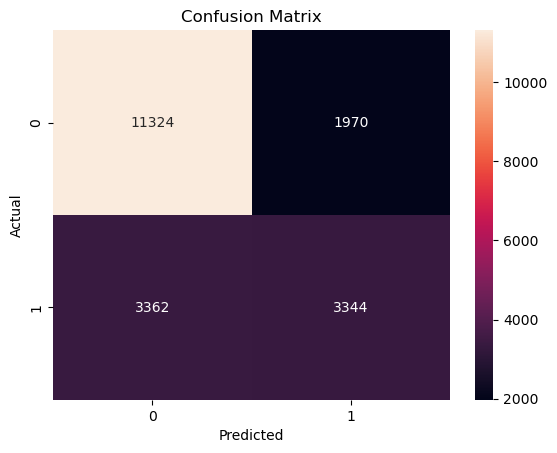

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix Analysis:
- The model correctly predicts most non-churn customers.
- Some churn cases are misclassified.

The model performs well but can be improved in identifying churned customers.

### Business Insight:
-Missing Churned customers (False Negatives) is costly because these customers leave without intervention.

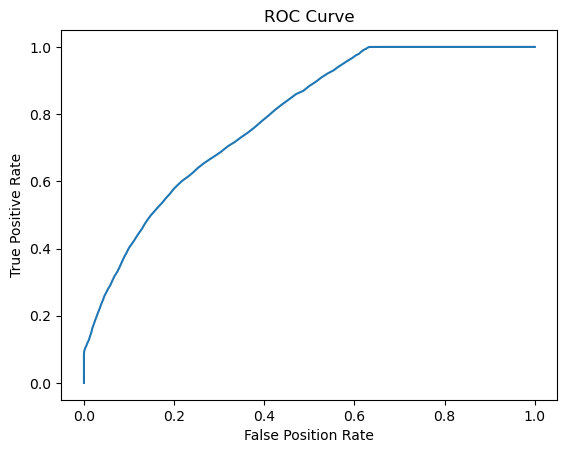

In [17]:
from sklearn.metrics import roc_curve, auc
y_prob=rf.predict_proba(x_test)[:,1]
fpr, tpr,_=roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Position Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### ROC Curve Analysis:
- The curve shows the model's ability to distinguish between churn and non-churn.

A higher curve indicates better performance. 

<Axes: >

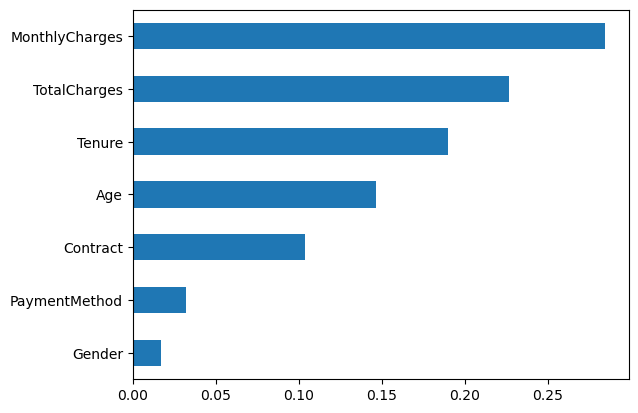

In [18]:
importance=pd.Series(rf.feature_importances_,
                     index=x.columns)
importance.sort_values().plot(kind='barh')

 ### Feature Importance Analysis:
- **MonthlyCharges** is the most important factor influencing customer churn.
- **TotalCharges** and **Tenure** also have a strong impact on predicting churn.
- **Age** and **Contract** have moderate importance.
- **PaymentMethod** and **Gender** contribute very little to the model.
**Conclusion:**
  Pricing-related features and customer duration (tenure) are the key drivers of customer churn.

### Business Recommendation:
- Customers with high monthly charges are more likely to churn - offer better pricing and value.
- Customers with low tenure (new customers) are more likely to leave - improve onboarding experience.
- Focus retention strategies on early-stage customers. 

### Final Conclusion:
- Customer churn is mainly driven by pricing and contract flexibility.
- customers with higher monthly charges and shorter tenure are more likely to churn.
- Long-term contracts significantly reduce churn.

Machine learning models like Random Forest can effectively predict churn and help businesses take proactive actions.